## Call a model

In [1]:
import os
from PIL import Image
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.models.train import QualityDescriptor

system = QualityDescriptor.load_from_checkpoint('/mnt/QUANTGEN/SRCDATA/DL/Faxitron/checkpoints/pepper/SQP_pepper/SGD/cp_epoch=340_val_loss=0.418_val_F1=0.837.ckpt')

In [2]:
system.hparams

Namespace(dataloader={'num_workers': 12, 'train_batch_size': 256, 'val_batch_size': 256, 'sampler': 'default'}, dataset={'train_names_file': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/splits/pepper/TRAIN_balanced_2.txt', 'train_labels_file': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/splits/pepper/labels_train.txt', 'val_names_file': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/splits/pepper/VAL_balanced_2.txt', 'image_dir': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/images/pepper/', 'labels_file': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/labels/pepper/labels_balanced_2.csv', 'augmentation': 'light', 'size': [224, 224], 'mean': 0.1717, 'std': 0.0773}, design={'loss': 'CE', 'optimizer': 'adam', 'scheduler': 'Cosine', 'lr': 1e-05, 'lr_end': 1e-07, 'weight_decay': 0, 'max_grad_norm': 10.0, 'max_epochs': 1000, 'accum_batches': 1, 'mixup': True, 'alpha': 0.4, 'n_checkpoints': 5, 'es_patience': 21}, experiment_name='SQP_pepper', gpus=[0, 1], model={'load_checkpoint_file': None, 'freeze'

In [3]:
model = system.model

model.freeze()

for param in model.parameters():
    param.requires_grad_(False)

## Get a test image and a label

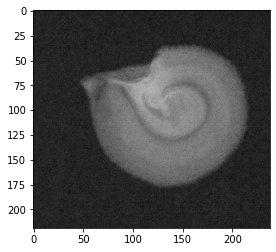

In [4]:
path = '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/images/pepper/' #Image Path

test_img_name = '5c1204ea22ddb32f7cef8f0a_30.jpg'
img_origin = Image.open(path + test_img_name)
plt.imshow(img_origin)
plt.show()

In [5]:
df = pd.read_csv('datasets/labels/pepper/labels.csv') # label dataframe
df

,Unnamed: 0,filename,label
0,0,5c4ef33d22ddb30e00052879_0.jpg,geen prime
1,1,5c4ef33d22ddb30e00052879_1.jpg,geen prime
2,2,5c4ef33d22ddb30e00052879_2.jpg,geen prime
3,3,5c4ef33d22ddb30e00052879_3.jpg,geen prime
4,4,5c4ef33d22ddb30e00052879_4.jpg,geen prime
...,...,...,...
131361,131363,5e1ef0f522ddb311bccf7f2e_45.jpg,geen prime
131362,131364,5e1ef0f522ddb311bccf7f2e_46.jpg,geen prime
131363,131365,5e1ef0f522ddb311bccf7f2e_47.jpg,geen prime
131364,131366,5e1ef0f522ddb311bccf7f2e_48.jpg,geen prime


In [6]:
# different dataframe filtering 1
label_row = df.loc[df['filename'] == test_img_name]['label']
print(label_row)

73643    prime
Name: label, dtype: object


In [7]:
# different dataframe filtering 2
label_row2 = df.loc[df['filename'] == test_img_name, 'label']
print(label_row2)

73643    prime
Name: label, dtype: object


In [8]:
label = label_row.item()
print(label)

prime


In [9]:
img_label = label_row2.iloc[0]
img_label

'prime'

In [10]:
def actual_label(jpg_file):
    '''put jpg_file name then returns the actual label of the image
       jpg_file should be string format'''
    
    df = pd.read_csv('datasets/labels/pepper/labels.csv')
    img_label = df.loc[df['filename'] == jpg_file, 'label'].iloc[0]
    return img_label

In [11]:
actual_label(test_img_name)

'prime'

# Preprocessing 
## Denoise the image and check the extracted noise 

In [ ]:
img = np.uint8(img_origin)
dst = cv2.fastNlMeansDenoisingColored(img,None,3)#,10,7,21)
plt.subplot(121),plt.imshow(img)
plt.subplot(122),plt.imshow(dst)
plt.axis.off()
plt.show()

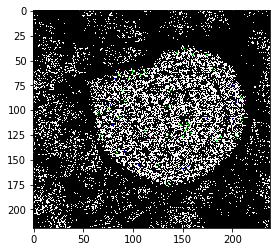

In [13]:
plt.imshow(abs(img - dst), cmap='gray') # noise extracted

In [14]:
cv2.imwrite('dst_xray.jpg', dst)

True

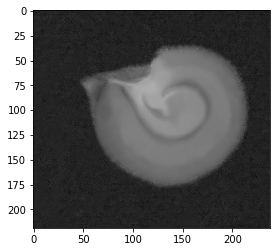

In [15]:
img_denoised = Image.open('dst_xray.jpg')
plt.imshow(img_denoised)
plt.show()

## Resize and Transform to Tensor

In [16]:
import torch
import torchvision
from torchvision import transforms

In [17]:
def transform(original_x, shape=224):
    
    transform = transform = transforms.Compose([
    transforms.Resize(shape),
    transforms.CenterCrop(shape),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1717, 0.1717, 0.1717],
                         std=[0.0773, 0.0773, 0.0773]),
    ])
    
    transformed_x = transform(original_x).unsqueeze(0)
    
    return transformed_x

In [18]:
x = transform(img_origin)
x.shape

torch.Size([1, 3, 224, 224])

In [19]:
denoised_x = transform(img_denoised)
denoised_x.shape

torch.Size([1, 3, 224, 224])

In [20]:
# "class_id" info is in seedqualitypredictor.src.data.stats.py file 

LABEL_TO_CLASS = {0: "abnormaal",
                  1: "geen prime",
                  2: "licht prime",
                  3: "prime",
                  4: "voorkiem"}

In [21]:
def predict_class(transformed_x):
    """put transformed_x then returns the predicted class
       trnasformed_x should be resized, normalized and is in a 
       tensor format"""
    pred = model(transformed_x)
    probs = torch.softmax(pred.detach().cpu(), dim=1).numpy()
    probs = np.argmax(probs, axis=1)
    pred_class = probs[0]
    
    return pred_class

In [22]:
predict_class(x)

3

In [23]:
LABEL_TO_CLASS[predict_class(x)]

'prime'

In [24]:
def resize(input_x, shape1=224, shape2=224):
    """put loaded PIL image and resize the image for given parameters.
       convert PIL image to numpy array and return the array."""
    
    resize = transforms.Resize([shape1,shape1])
    resize = resize(input_x)
    array = np.array(resize)
    
    return array

In [25]:
re = resize(img_origin)

# TorchRay Attribution Method Implementation\

https://github.com/facebookresearch/TorchRay/blob/master/docs/attribution.rst

TorchRay implements the following methods:

* Backpropagation methods
    
  * Gradient (:mod:`.gradient`)
  * Deconvolution (:mod:`.deconvnet`)
  * Guided backpropagation (:mod:`.guided_backprop`)
  * Grad-CAM (:mod:`.grad_cam`)
  * Excitation backpropagation (:mod:`.excitation_backprop`)
  * Linear Approximation (:mod:`.linear_approximation`)

In [26]:
x.requires_grad = True
denoised_x.requires_grad = True

# Gradient 

In [27]:
from torchray.attribution.gradient import gradient

gradient = gradient(model, x, predict_class(x))     # FORMAT saliency = gradient(model, x, category_id)
print(gradient.shape)

torch.Size([1, 1, 224, 224])


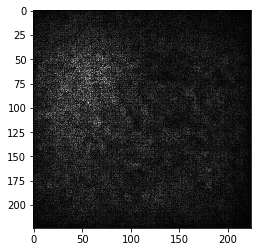

In [28]:
plt.imshow(gradient.detach().cpu()[0][0], cmap='gray')
plt.show()

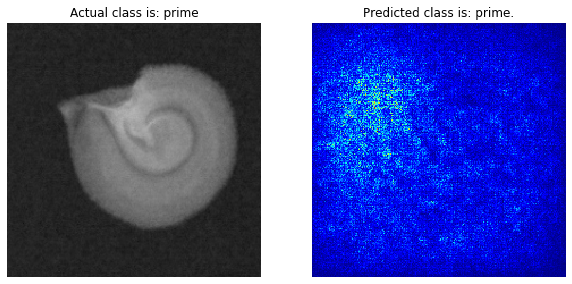

In [29]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,10), squeeze=False)
# original image
axs[0][0].imshow(resize(img_origin), cmap='gray') 
axs[0][0].set_title('Actual class is: {}'.format(actual_label(test_img_name)), fontsize=12)
axs[0][0].axis('off')

# attribution visualization
axs[0][1].imshow(gradient.detach().cpu()[0][0], cmap='jet')
axs[0][1].set_title('Predicted class is: {}.'.format(LABEL_TO_CLASS[predict_class(x)]), fontsize=12) 
axs[0][1].axis('off')

plt.show()

# Deconvolution

In [30]:
from torchray.attribution.deconvnet import deconvnet

deconv = deconvnet(model, x, predict_class(x))

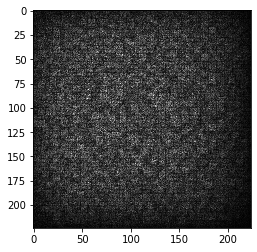

In [31]:
plt.imshow(deconv.detach().cpu()[0][0], cmap='gray')
plt.show()

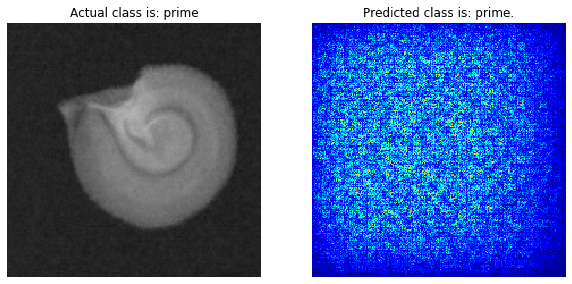

In [32]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,10), squeeze=False)
# original image
axs[0][0].imshow(resize(img_origin), cmap='gray') 
axs[0][0].set_title('Actual class is: {}'.format(actual_label(test_img_name)), fontsize=12)
axs[0][0].axis('off')

# attribution visualization
axs[0][1].imshow(deconv.detach().cpu()[0][0], cmap='jet')
axs[0][1].set_title('Predicted class is: {}.'.format(LABEL_TO_CLASS[predict_class(x)]), fontsize=12) 
axs[0][1].axis('off')

plt.show()

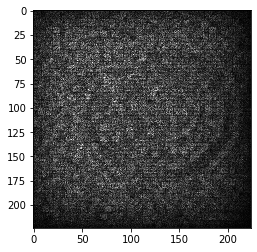

In [33]:
deconv_denoised = deconvnet(model, denoised_x, predict_class(denoised_x))
plt.imshow(deconv_denoised.detach().cpu()[0][0], cmap='gray')
plt.show()

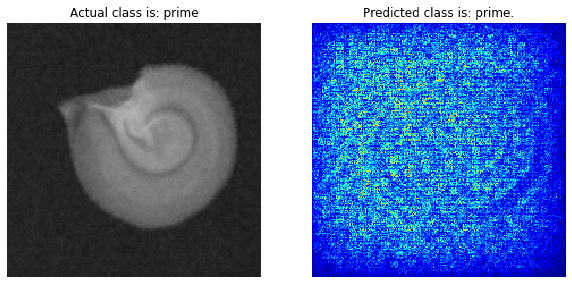

In [34]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,10), squeeze=False)
# original image
axs[0][0].imshow(resize(img_origin) , cmap='gray') 
axs[0][0].set_title('Actual class is: {}'.format(actual_label(test_img_name)), fontsize=12)
axs[0][0].axis('off')

# attribution visualization
axs[0][1].imshow(deconv_denoised.detach().cpu()[0][0], cmap='jet')
axs[0][1].set_title('Predicted class is: {}.'.format(LABEL_TO_CLASS[predict_class(denoised_x)]), fontsize=12) 
axs[0][1].axis('off')

plt.show()

# Guided Backpropagation

In [35]:
from torchray.attribution.guided_backprop import guided_backprop

# Guided backprop.
guided_bp = guided_backprop(model, x, predict_class(x))

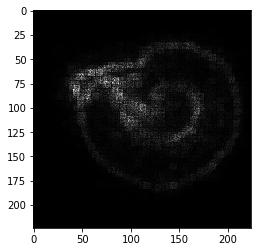

In [36]:
plt.imshow(guided_bp.detach().cpu()[0][0], cmap='gray')
plt.show()

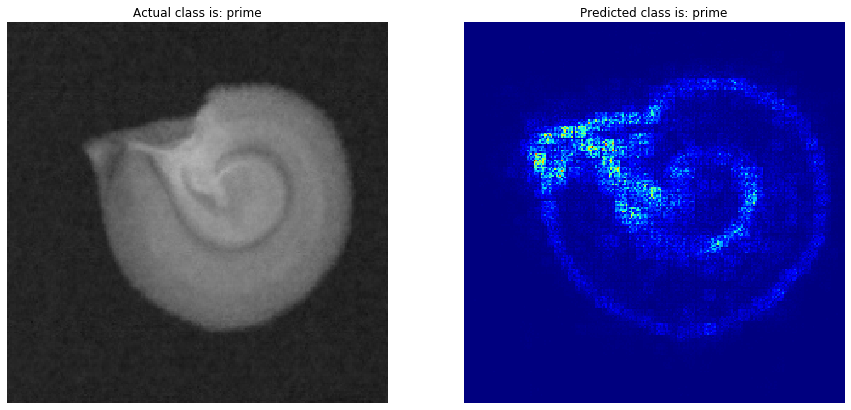

In [37]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,15), squeeze=False)
# plt.subplots_adjust(left=0.15, right=1, bottom=0.1, top=0.6, wspace=0.2, hspace=0.2)

# original image
axs[0][0].imshow(resize(img_origin), cmap='gray') 
axs[0][0].set_title('Actual class is: {}'.format(actual_label(test_img_name)), fontsize=12)
axs[0][0].axis('off')
                    
# attribution visualization
axs[0][1].imshow(guided_bp.detach().cpu()[0][0], cmap='jet')
axs[0][1].set_title('Predicted class is: {}'.format(LABEL_TO_CLASS[predict_class(x)]), fontsize=12)
axs[0][1].axis('off')
                    
plt.show()                    

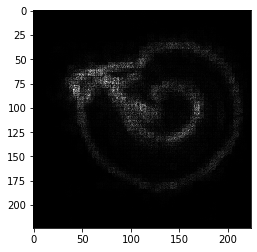

In [38]:
guided_bp_denoised = guided_backprop(model, denoised_x, predict_class(denoised_x))
plt.imshow(guided_bp_denoised.detach().cpu()[0][0], cmap='gray')
plt.show()

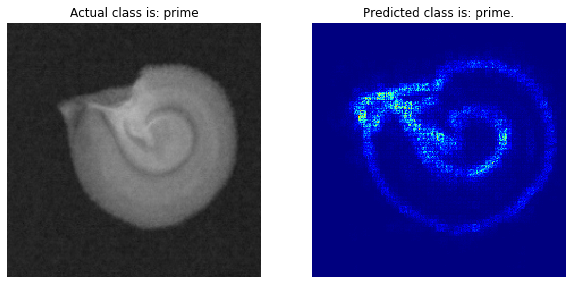

In [39]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,10), squeeze=False)
# original image
axs[0][0].imshow(resize(img_origin), cmap='gray') 
axs[0][0].set_title('Actual class is: {}'.format(actual_label(test_img_name)), fontsize=12)
axs[0][0].axis('off')

# attribution visualization
axs[0][1].imshow(guided_bp_denoised.detach().cpu()[0][0], cmap='jet')
axs[0][1].set_title('Predicted class is: {}.'.format(LABEL_TO_CLASS[predict_class(denoised_x)]), fontsize=12) 
axs[0][1].axis('off')

plt.show()

In [ ]:
val_ds = system.val_dataloader().dataset.names
val_ds

In [ ]:
for img_name in val_ds:    
    
    original = load_image(img_name) # use of function def laod_image
    transformed_x = transform(original) # use of function def transform 

    for param in model.parameters():
        param.requires_grad_(False)

    actual_class = actual_label(img_name) # use of function def actual_label
    pred_class = LABEL_TO_CLASS[predict_class(transformed_x)] # use of function def predict_class

    # Plot
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,15), squeeze=False)
    fig.tight_layout() 

    resized_img = resize(original) # use of function def resize
    axs[0][0].imshow(np.array(resized_img), cmap='gray')
    axs[0][0].set_title('Actual class is: {}'.format(actual_class), fontsize=12)  

    #for class_idx in range(5)
    guided_bp = guided_backprop(model, transformed_x, predict_class(transformed_x)) 

    axs[0][1].imshow(guided_bp.detach().cpu()[0][0], cmap='jet')
    axs[0][1].set_title('Predicted class is: {}'.format(pred_class), fontsize=12)

    axs[0][2].text(0.2, 0.4, "Class Label \n{0: abnormaal, \n  1: geen prime, \n  2: licht prime, \n  3: prime, \n  4: voorkiem}", fontsize=12)
    axs[0][2].axis('off')

    # Save the plot figure     
    if actual_class == 'abnormaal':
        if actual_class == pred_class:
            fig.savefig('Guided_Backpropagation_Report/Class0_Abnormaal/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig('Guided_Backpropagation_Report/Class0_Abnormaal/Wrong_Pred/'+ img_name)
            plt.close(fig)
            
    elif actual_class == 'geen prime':
        if actual_class == pred_class:
            fig.savefig('Guided_Backpropagation_Report/Class1_GeenPrime/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig('Guided_Backpropagation_Report/Class1_GeenPrime/Wrong_Pred/'+ img_name)
            plt.close(fig)

    elif actual_class == 'licht prime':
        if actual_class == pred_class:
            fig.savefig('Guided_Backpropagation_Report/Class2_LichtPrime/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig('Guided_Backpropagation_Report/Class2_LichtPrime/Wrong_Pred/'+ img_name)
            plt.close(fig)

    elif actual_class == 'prime':
        if actual_class == pred_class:
            fig.savefig('Guided_Backpropagation_Report/Class3_Prime/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig('Guided_Backpropagation_Report/Class3_Prime/Wrong_Pred/'+ img_name)
            plt.close(fig)  
    
    else: 
        if actual_class == pred_class:
            fig.savefig('Guided_Backpropagation_Report/Class4_Voorkiem/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig('Guided_Backpropagation_Report/Class4_Voorkiem/Wrong_Pred/'+ img_name)
            plt.close(fig) 

In [40]:
!zip -r PepperSeed_Guided_BP_Report /home/SOKI/ImageFiles/xray_seed/seedqualitypredictor
/Guided_Backpropagation_Report/

  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/ (stored 0%)
  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/.dvc/ (stored 0%)
  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/.dvc/config (deflated 19%)
  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/.dvc/.gitignore (deflated 28%)
  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/TorchRay-RemovingNoise.ipynb (deflated 27%)
  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/setup.py (deflated 30%)
  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/requirements.txt (deflated 38%)
  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/.ipynb_checkpoints/ (stored 0%)
  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/.ipynb_checkpoints/Other_Attribution_Methods-checkpoint.ipynb (deflated 79%)
  adding: home/SOKI/ImageFiles/xray_seed/seedqualitypredictor/.ipynb_checkpoints/Grad_CAM_PepperSeed-checkpoint.ipynb (deflated 51%)
  adding: h

NameError: name 'Guided_Backpropagation_Report' is not defined

# Grad-CAM

In [41]:
from torchray.attribution.grad_cam import grad_cam

gcam_bp = grad_cam(model, x, predict_class(x), saliency_layer='encoder.layer2')

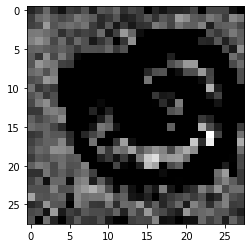

In [42]:
plt.imshow(gcam_bp.detach().cpu()[0][0], cmap='gray')
plt.show()

In [43]:
gcam_bp.shape

torch.Size([1, 1, 28, 28])

In [44]:
resizing = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224), interpolation=2),
    transforms.ToTensor()
])
s = gcam_bp[0].detach().cpu() #Gradient
s = s - s.min()
s = s / s.max()
saliency_res = resizing(s)

In [45]:
saliency_res.shape

torch.Size([1, 224, 224])

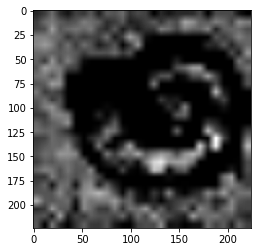

In [46]:
plt.imshow(saliency_res[0], cmap='gray')
plt.show()

In [47]:
def gcam(x, class_index, target_layer):
    """Convert activation and gradient of input x to a Grad-CAM saliency map"""
    
    from torchray.attribution.grad_cam import grad_cam
    
    model = system.model
    
    for param in model.parameters():
        param.requires_grad_(False)
    
    gcam = grad_cam(model, x, class_index, saliency_layer='encoder.layer'+ str(target_layer))
    
    s_map = gcam[0].detach().cpu()
    s_map = s_map - s_map.min()
    s_map = s_map / s_map.max()
    
    resize_trans = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224,224), interpolation=2),
        transforms.ToTensor()
        ])
    
    resized_s_map = resize_trans(s_map)
    
    return resized_s_map

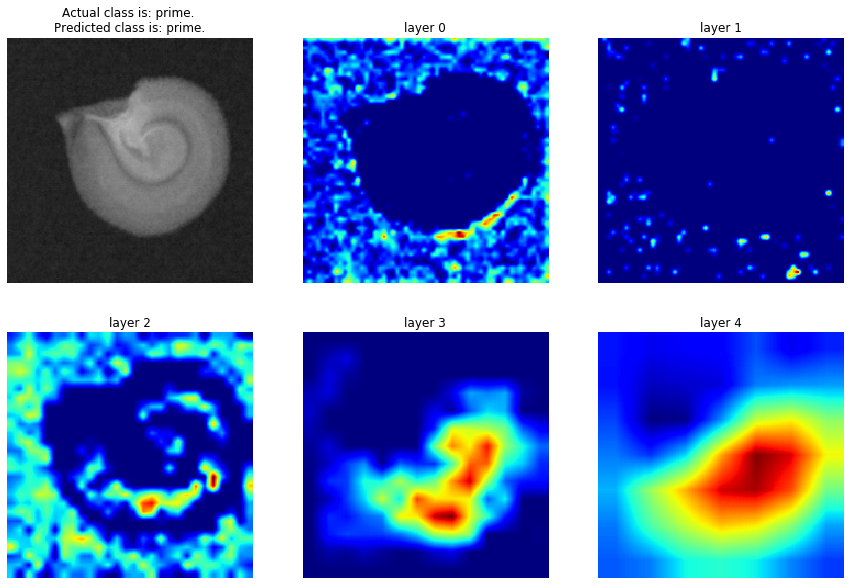

In [50]:
# subplot 
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15,15),squeeze=False)
plt.subplots_adjust(left=0.125, right=0.9, bottom=0.1, top=0.6, wspace=0.2, hspace=0.2)

layer_idx = 0

# layers by classes
for i in range(2):
    for j in range(3):
        if (i==0) & (j==0):
            # original image
            axs[0][0].imshow(resize(img_origin), cmap='gray') # use of function def resize 

            # use of functions def actual_label and def predict_class
            axs[0][0].set_title('Actual class is: {}. \nPredicted class is: {}.'.format(
                actual_label(test_img_name), LABEL_TO_CLASS[predict_class(x)]), fontsize=12) 
            axs[0][0].axis('off')

        else: 
            # use of function def gcam
            s_map = gcam(x, class_index= predict_class(x), target_layer=layer_idx) 
            axs[i][j].imshow(s_map[0], cmap='jet')
            axs[i][j].set_title('layer {}'.format(layer_idx), fontsize=12)      
            axs[i][j].axis('off')
            layer_idx += 1

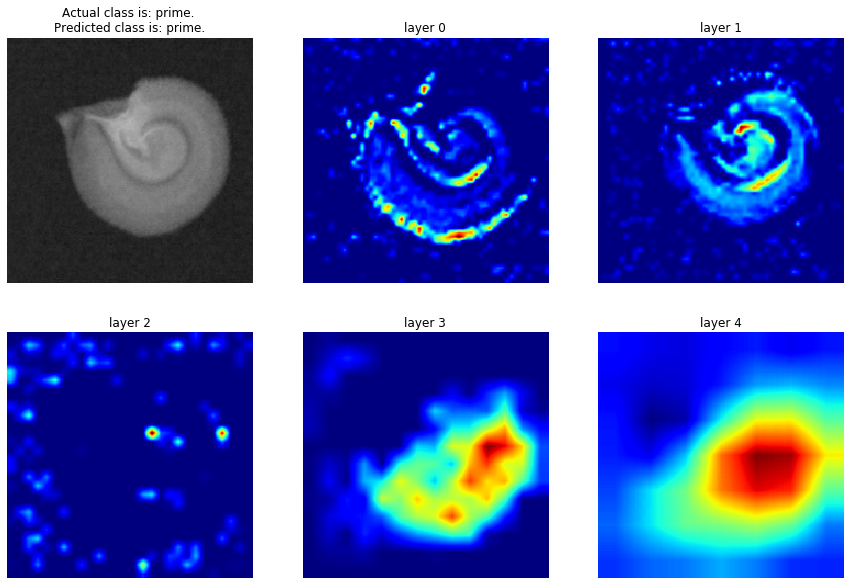

In [75]:
# subplot 
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15,15),squeeze=False)
plt.subplots_adjust(left=0.125, right=0.9, bottom=0.1, top=0.6, wspace=0.2, hspace=0.2)

layer_idx = 0

# layers by classes
for i in range(2):
    for j in range(3):
        if (i==0) & (j==0):
            # original image
            axs[0][0].imshow(resize(img_origin), cmap='gray') # use of function def resize 

            # use of functions def actual_label and def predict_class
            axs[0][0].set_title('Actual class is: {}. \nPredicted class is: {}.'.format(
                actual_label(test_img_name), LABEL_TO_CLASS[predict_class(x)]), fontsize=12) 
            axs[0][0].axis('off')

        else: 
            # use of function def gcam
            s_map = gcam(denoised_x, class_index= predict_class(denoised_x), target_layer=layer_idx) 
            axs[i][j].imshow(s_map[0], cmap='jet')
            axs[i][j].set_title('layer {}'.format(layer_idx), fontsize=12)      
            axs[i][j].axis('off')
            layer_idx += 1

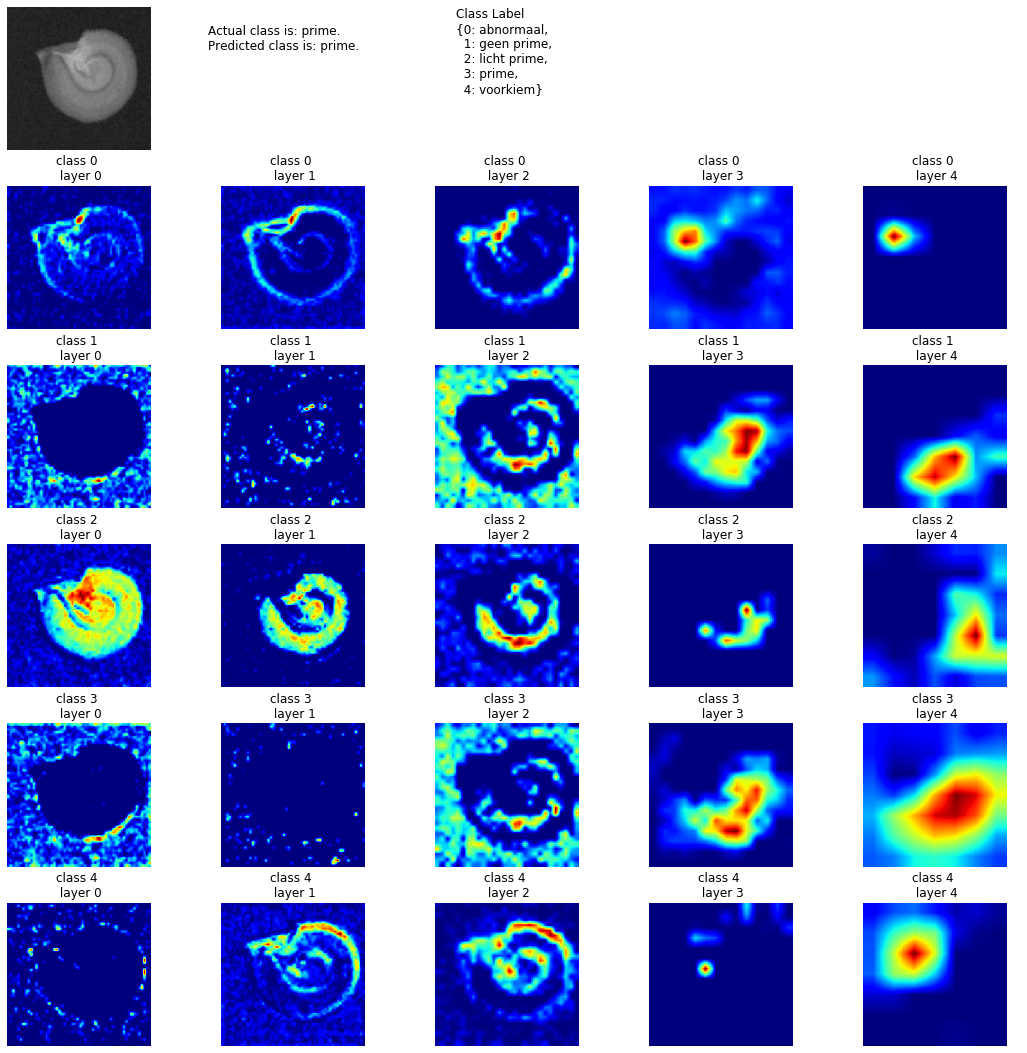

In [51]:
# subplot 
layer_index = list(range(5))
class_index = list(range(5))
fig, axs = plt.subplots(nrows=6, ncols=5, figsize=(15,15), squeeze=False)
fig.tight_layout(pad=1, h_pad=1.5, w_pad=None)

# original image
resized_img = resize(img_origin) # use of function def resize 
axs[0][0].imshow(np.array(resized_img), cmap='gray') 

# use of functions def actual_label and def predict_class
axs[0][0].axis('off')
axs[0][1].text(0.0, 0.7,'Actual class is: {}. \nPredicted class is: {}.'.format(actual_label(test_img_name), LABEL_TO_CLASS[predict_class(x)]), fontsize=12) 
axs[0][1].axis('off')
axs[0][2].text(0.2, 0.4, "Class Label \n{0: abnormaal, \n  1: geen prime, \n  2: licht prime, \n  3: prime, \n  4: voorkiem}", fontsize=12)
axs[0][2].axis('off')
axs[0][3].axis('off')
axs[0][4].axis('off')

# layers by classes
for c_idx in class_index:
    for l_idx in layer_index:
        s_map = gcam(x, class_index= c_idx, target_layer=l_idx) # use of function def gcam
        
        axs[c_idx+1][l_idx].imshow(s_map[0], cmap='jet')
        axs[c_idx+1][l_idx].set_title('class {} \n layer {}'.format(c_idx, l_idx), fontsize=12)      
        axs[c_idx+1][l_idx].axis('off')

In [ ]:
for img_name in val_ds:
    
    img_origin = Image.open(path+img_name)
    transformed_x = transform(img_origin) # use of function def transform
    
    for param in model.parameters():
        param.requires_grad_(False)
    
    actual_class = actual_label(img_name) # use of function def actual_label
    pred_class = LABEL_TO_CLASS[predict_class(transformed_x)] # use of function def predict_class
    
 
    fig, axs = plt.subplots(nrows=6, ncols=5, figsize=(15,15), squeeze=False)
    fig.tight_layout(pad=1, h_pad=1.5, w_pad=None) 

    # original image              
    axs[0][0].imshow(resize(img_origin), cmap='gray')  # use of function def resize
    axs[0][0].axis('off')
    axs[0][1].text(0.0, 0.7,'Actual class is: {}. \nPredicted class is: {}.'.format(actual_class, pred_class), fontsize=12)
    axs[0][1].axis('off')
    axs[0][2].text(0.2, 0.5, "Class Label \n{0: abnormaal, \n  1: geen prime, \n  2: licht prime, \n  3: prime, \n  4: voorkiem}", fontsize=12)
    axs[0][2].axis('off')
    axs[0][3].axis('off')
    axs[0][4].axis('off')

    # subplot layers by classes
    layer_index = list(range(5))
    class_index = list(range(5))
    
    # layers by classes
    for c_idx in class_index:
        for l_idx in layer_index:
            s_map = gcam(transformed_x, class_index= c_idx, target_layer=l_idx) # use of function def grad_cam

            axs[c_idx+1][l_idx].imshow(s_map[0], cmap='jet')
            axs[c_idx+1][l_idx].set_title('class {} \n layer {}'.format(c_idx, l_idx), fontsize=12)      
            axs[c_idx+1][l_idx].axis('off')
    
    
    # Save the plot figure     
    if actual_class == 'abnormaal':
        if actual_class == pred_class:
            fig.savefig(current + '/GradCAM_Torchray_Report/GradCAM_Class0_Abnormaal/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig(current +'/GradCAM_Torchray_Report/GradCAM_Class0_Abnormaal/Wrong_Pred/'+ img_name)
            plt.close(fig)
            
    elif actual_class == 'geen prime':
        if actual_class == pred_class:
            fig.savefig(current +'/GradCAM_Torchray_Report/GradCAM_Class1_GeenPrime/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig(current +'/GradCAM_Torchray_Report/GradCAM_Class1_GeenPrime/Wrong_Pred/'+ img_name)
            plt.close(fig)

    elif actual_class == 'licht prime':
        if actual_class == pred_class:
            fig.savefig(current +'/GradCAM_Torchray_Report/GradCAM_Class2_LichtPrime/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig(current +'/GradCAM_Torchray_Report/GradCAM_Class2_LichtPrime/Wrong_Pred/'+ img_name)
            plt.close(fig)

    elif actual_class == 'prime':
        if actual_class == pred_class:
            fig.savefig(current +'/GradCAM_Torchray_Report/GradCAM_Class3_Prime/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig(current +'/GradCAM_Torchray_Report/GradCAM_Class3_Prime/Wrong_Pred/'+ img_name)
            plt.close(fig)  
    
    else: 
        if actual_class == pred_class:
            fig.savefig(current +'/GradCAM_Torchray_Report/GradCAM_Class4_Voorkiem/Correct_Pred/'+ img_name)
            plt.close(fig)
        else: 
            fig.savefig(current +'/GradCAM_Torchray_Report/GradCAM_Class4_Voorkiem/Wrong_Pred/'+ img_name)
            plt.close(fig) 

In [ ]:
!zip -r PepperSeed_GradCAM_Pytorch_Report /home/SOKI/ImageFiles/xray_seed/seedqualitypredictor
/GradCAM_Torchray_Report/

# Excitation backpropagation

In [52]:
from torchray.attribution.excitation_backprop import excitation_backprop

# Contrastive excitation backprop.

excitation_bp = excitation_backprop(model, x, predict_class(x), saliency_layer='encoder.layer2')

# FORMAT: saliency = excitation_backprop(model, x, category_id, saliency_layer='features.9') 

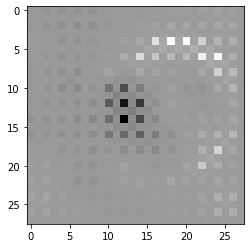

In [53]:
plt.imshow(excitation_bp.detach().cpu()[0][0], cmap='gray')
plt.show()

In [54]:
excitation_bp.shape

torch.Size([1, 1, 28, 28])

In [58]:
s = excitation_bp[0].detach().cpu() #Gradient
s = s - s.min()
s = s / s.max()
saliency_res = resizing(s)

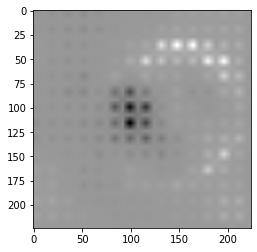

In [59]:
plt.imshow(saliency_res[0], cmap='gray')
plt.show()

In [60]:
def excitation_backprop(x, class_index, target_layer):
    """Convert activation and gradient of input x to an excitation backpropagation saliency map"""
    
    from torchray.attribution.excitation_backprop import excitation_backprop
    
    model = system.model
    
    for param in model.parameters():
        param.requires_grad_(False)
    
    excitation = excitation_backprop(model, x, class_index, saliency_layer='encoder.layer'+ str(target_layer))
    
    s_map = excitation[0].detach().cpu()
    s_map = s_map - s_map.min()
    s_map = s_map / s_map.max()
    
    resize_trans = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224,224), interpolation=2),
        transforms.ToTensor()
        ])
    
    resized_s_map = resize_trans(s_map)
    
    return resized_s_map

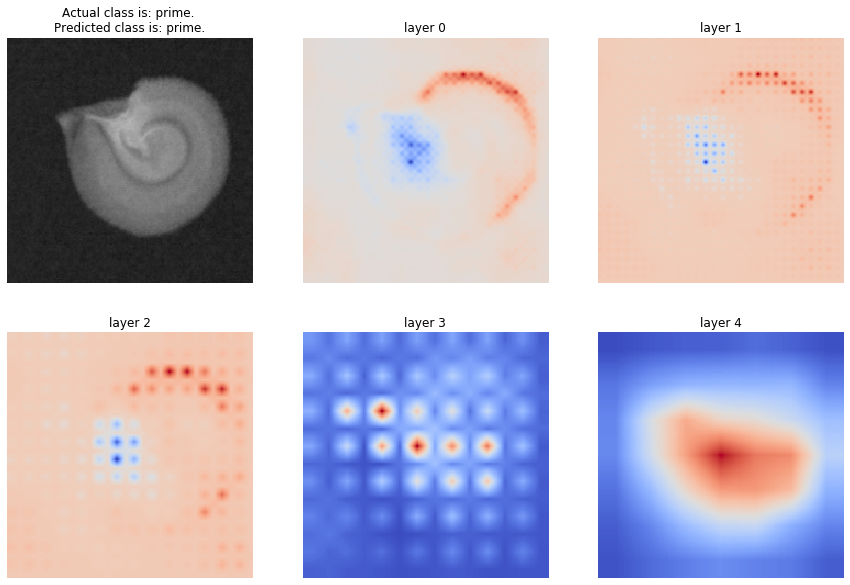

In [68]:
# subplot 
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15,15),squeeze=False)
plt.subplots_adjust(left=0.125, right=0.9, bottom=0.1, top=0.6, wspace=0.2, hspace=0.2)

#fig.tight_layout(2, 3, [.01 .03], [.1 .01], [.01 .01])
layer_idx = 0

# layers by classes
for i in range(2):
    for j in range(3):
        if (i==0) & (j==0):
            # original image
            resized_img = resize(img_origin) # use of function def resize 
            axs[0][0].imshow(np.array(resized_img), cmap='gray') 

            # use of functions def actual_label and def predict_class
            axs[0][0].set_title('Actual class is: {}. \nPredicted class is: {}.'.format(
                'prime', LABEL_TO_CLASS[predict_class(x)]), fontsize=12) 
            axs[0][0].axis('off')

        else: 
            # use of function def excitation_backprop
            s_map = excitation_backprop(x, class_index= predict_class(x), target_layer=layer_idx) 
            axs[i][j].imshow(s_map[0], cmap='coolwarm')
            axs[i][j].set_title('layer {}'.format(layer_idx), fontsize=12)      
            axs[i][j].axis('off')
            layer_idx += 1

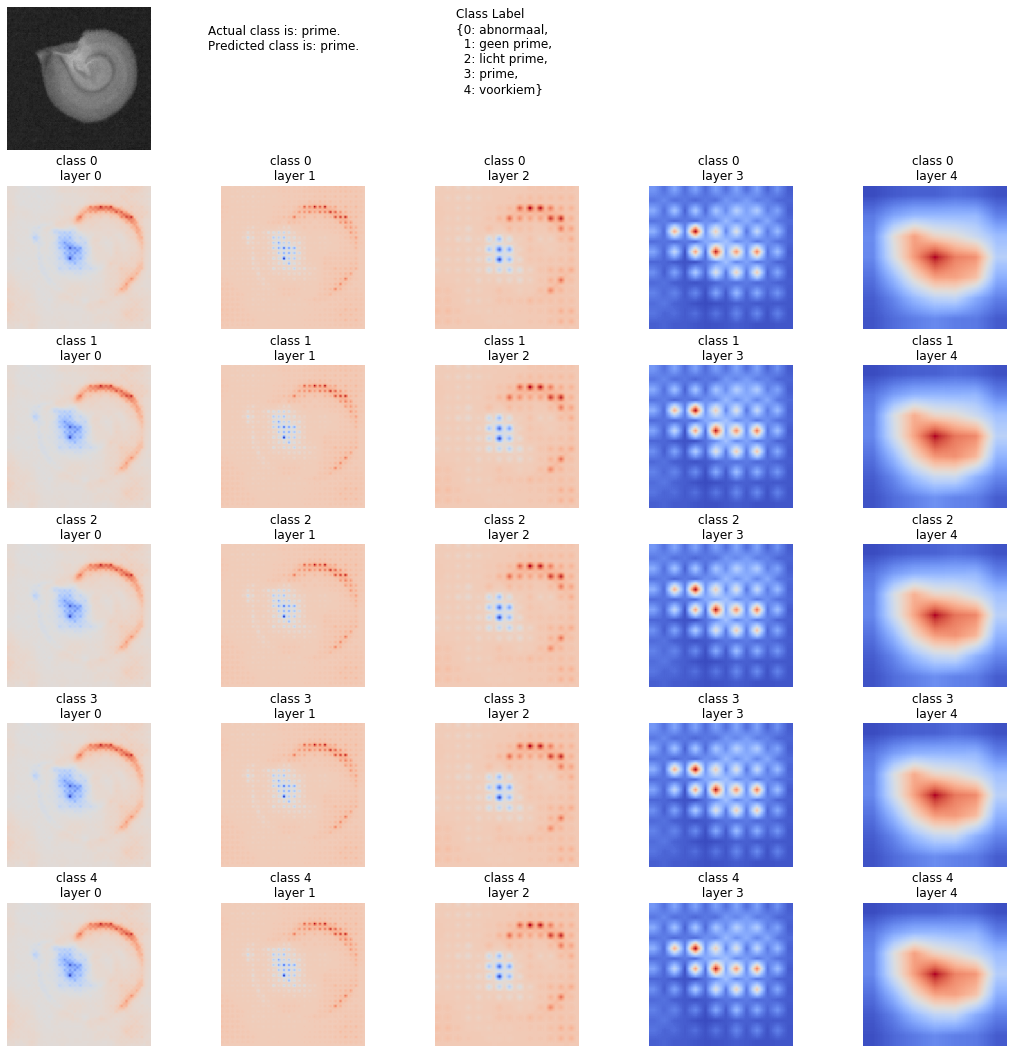

In [69]:
# subplot 
layer_index = list(range(5))
class_index = list(range(5))
fig, axs = plt.subplots(nrows=6, ncols=5, figsize=(15,15), squeeze=False)
fig.tight_layout(pad=1, h_pad=1.5, w_pad=None)

# original image
axs[0][0].imshow(resize(img_origin), cmap='gray') # use of function def resize 
axs[0][0].axis('off')

# use of functions def actual_label and def predict_class
axs[0][1].text(0.0, 0.7,'Actual class is: {}. \nPredicted class is: {}.'.format('prime', LABEL_TO_CLASS[predict_class(x)]), fontsize=12) 
axs[0][1].axis('off')
axs[0][2].text(0.2, 0.4, "Class Label \n{0: abnormaal, \n  1: geen prime, \n  2: licht prime, \n  3: prime, \n  4: voorkiem}", fontsize=12)
axs[0][2].axis('off')
axs[0][3].axis('off')
axs[0][4].axis('off')

# layers by classes
for c_idx in class_index:
    for l_idx in layer_index:
        s_map = excitation_backprop(x, class_index= c_idx, target_layer=l_idx) # use of function def excitation_backprop
        
        axs[c_idx+1][l_idx].imshow(s_map[0], cmap='coolwarm')
        axs[c_idx+1][l_idx].set_title('class {} \n layer {}'.format(c_idx, l_idx), fontsize=12)      
        axs[c_idx+1][l_idx].axis('off')

# Linear Approximation

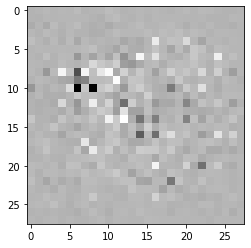

In [70]:
from torchray.attribution.linear_approx import linear_approx

# Linear approximation backprop.
linear_appx = linear_approx(model, x, predict_class(x), saliency_layer='encoder.layer2')
plt.imshow(linear_appx.detach().cpu()[0][0],cmap='gray')
plt.show()

In [71]:
linear_appx.shape

torch.Size([1, 1, 28, 28])

In [72]:
def linear_approximation(x, class_index, target_layer):
    """Convert activation and gradient of input x to a linear approximation saliency map"""
     
    from torchray.attribution.linear_approx import linear_approx
    
    model = system.model
    
    for param in model.parameters():
        param.requires_grad_(False)
    
    l_ap = linear_approx(model, x, class_index, saliency_layer='encoder.layer'+ str(target_layer))
    
    s_map = l_ap[0].detach().cpu()
    s_map = s_map - s_map.min()
    s_map = s_map / s_map.max()
    
    resize_trans = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224,224), interpolation=2),
        transforms.ToTensor()
        ])
    
    resized_s_map = resize_trans(s_map)
    
    return resized_s_map

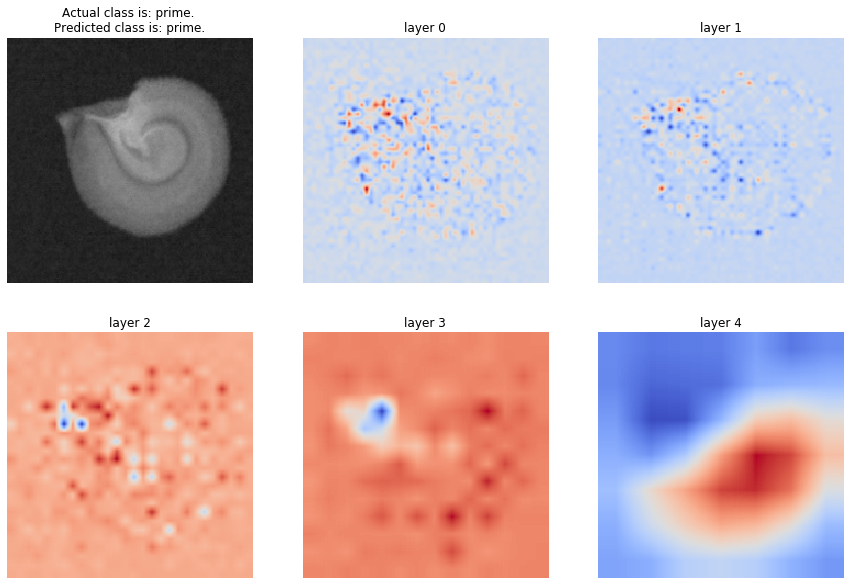

In [73]:
# subplot 
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15,15),squeeze=False)
plt.subplots_adjust(left=0.125, right=0.9, bottom=0.1, top=0.6, wspace=0.2, hspace=0.2)

#fig.tight_layout(2, 3, [.01 .03], [.1 .01], [.01 .01])
layer_idx = 0

# layers by classes
for i in range(2):
    for j in range(3):
        if (i==0) & (j==0):
            # original image
            resized_img = resize(img_origin) # use of function def resize 
            axs[0][0].imshow(np.array(resized_img), cmap='gray') 

            # use of functions def actual_label and def predict_class
            axs[0][0].set_title('Actual class is: {}. \nPredicted class is: {}.'.format(
                actual_label(test_img_name), LABEL_TO_CLASS[predict_class(x)]), fontsize=12) 
            axs[0][0].axis('off')

        else: 
            # use of function def linear_approximation
            s_map = linear_approximation(x, class_index= predict_class(x), target_layer=layer_idx) 
            axs[i][j].imshow(s_map[0], cmap='coolwarm')
            axs[i][j].set_title('layer {}'.format(layer_idx), fontsize=12)      
            axs[i][j].axis('off')
            layer_idx += 1

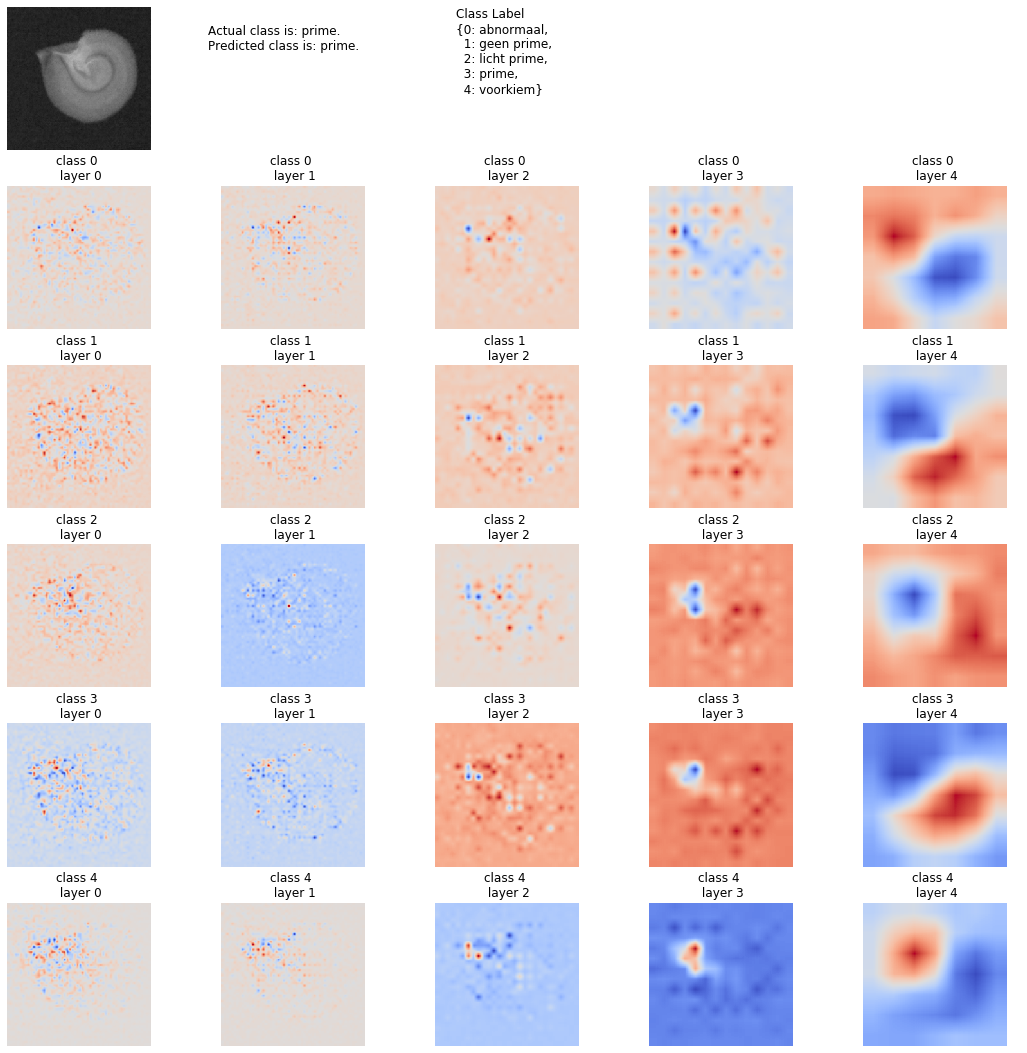

In [74]:
# subplot 
layer_index = list(range(5))
class_index = list(range(5))
fig, axs = plt.subplots(nrows=6, ncols=5, figsize=(15,15), squeeze=False)
fig.tight_layout(pad=1, h_pad=1.5, w_pad=None)

# original image
resized_img = resize(img_origin) # use of function def resize 
axs[0][0].imshow(np.array(resized_img), cmap='gray') 

# use of functions def actual_label and def predict_class
axs[0][0].axis('off')
axs[0][1].text(0.0, 0.7,'Actual class is: {}. \nPredicted class is: {}.'.format(actual_label(test_img_name), LABEL_TO_CLASS[predict_class(x)]), fontsize=12) 
axs[0][1].axis('off')
axs[0][2].text(0.2, 0.4, "Class Label \n{0: abnormaal, \n  1: geen prime, \n  2: licht prime, \n  3: prime, \n  4: voorkiem}", fontsize=12)
axs[0][2].axis('off')
axs[0][3].axis('off')
axs[0][4].axis('off')

# layers by classes
for c_idx in class_index:
    for l_idx in layer_index:
        s_map = linear_approximation(x, class_index= c_idx, target_layer=l_idx) # use of function def linear_approximation
        
        axs[c_idx+1][l_idx].imshow(s_map[0], cmap='coolwarm')
        axs[c_idx+1][l_idx].set_title('class {} \n layer {}'.format(c_idx, l_idx), fontsize=12)      
        axs[c_idx+1][l_idx].axis('off')